# Cryptocurrency Correlation Analysis
This notebook analyzes the correlation between 10 major cryptocurrencies
using both closing prices and daily returns. It generates heatmaps,
pairplots, and rolling correlation charts to understand how cryptocurrencies
move in relation to each other.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [5]:
os.makedirs("../data/correlation", exist_ok=True)

## Load Dataset
Load the preprocessed combined cryptocurrency dataset from `data/processed/`.

In [ ]:
df = pd.read_csv("../data/processed/combined_crypto_data.csv", parse_dates=["Date"])

print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print("Cryptos:", df["Crypto"].unique())
df.head()

Shape: (18250, 14)
Columns: ['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Crypto', 'Daily_Return', 'Log_Return', 'Price_Range', 'MA_7', 'MA_30', 'Volatility_7', 'Cumulative_Return']
Cryptos: ['ADA' 'BNB' 'BTC' 'DOGE' 'DOT' 'ETH' 'LINK' 'LTC' 'SOL' 'XRP']


,Date,Open,High,Low,Close,Volume,Crypto,Daily_Return,Log_Return,Price_Range,MA_7,MA_30,Volatility_7,Cumulative_Return
0,2021-01-01,0.181382,0.184246,0.172022,0.175350,1122218004,ADA,NaN,NaN,0.012224,NaN,NaN,NaN,0.000000
1,2021-01-02,0.175359,0.184253,0.169233,0.177423,1408849504,ADA,1.182210,0.011753,0.015020,NaN,NaN,NaN,1.182210
2,2021-01-03,0.177382,0.208679,0.173376,0.204995,2303857909,ADA,15.540266,0.144449,0.035303,NaN,NaN,NaN,16.906194
3,2021-01-04,0.205236,0.239661,0.194450,0.224762,3260699086,ADA,9.642667,0.092056,0.045211,NaN,NaN,NaN,28.179070
4,2021-01-05,0.224817,0.264886,0.208454,0.258314,4097207384,ADA,14.927800,0.139134,0.056432,NaN,NaN,NaN,47.313385


In [7]:
df = pd.read_csv("../data/processed/combined_crypto_data.csv")
df["Date"] = pd.to_datetime(df["Date"])

df.head()

,Date,Open,High,Low,Close,Volume,Crypto,Daily_Return,Log_Return,Price_Range,MA_7,MA_30,Volatility_7,Cumulative_Return
0,2021-01-01,0.181382,0.184246,0.172022,0.175350,1122218004,ADA,NaN,NaN,0.012224,NaN,NaN,NaN,0.000000
1,2021-01-02,0.175359,0.184253,0.169233,0.177423,1408849504,ADA,1.182210,0.011753,0.015020,NaN,NaN,NaN,1.182210
2,2021-01-03,0.177382,0.208679,0.173376,0.204995,2303857909,ADA,15.540266,0.144449,0.035303,NaN,NaN,NaN,16.906194
3,2021-01-04,0.205236,0.239661,0.194450,0.224762,3260699086,ADA,9.642667,0.092056,0.045211,NaN,NaN,NaN,28.179070
4,2021-01-05,0.224817,0.264886,0.208454,0.258314,4097207384,ADA,14.927800,0.139134,0.056432,NaN,NaN,NaN,47.313385


## Pivot Close Prices
Reshape the dataset so each cryptocurrency becomes a separate column.
This pivot format is required for computing pairwise correlations.

- **Rows:** Dates
- **Columns:** Each cryptocurrency
- **Values:** Closing price

In [ ]:
close_pivot = df.pivot(index="Date", columns="Crypto", values="Close")

print("Pivot Shape:", close_pivot.shape)
close_pivot.head()

Pivot Shape: (1825, 10)


Crypto,ADA,BNB,BTC,DOGE,DOT,ETH,LINK,LTC,SOL,XRP
Date,,,,,,,,,,
2021-01-01,0.175350,37.905010,29374.152344,0.005685,8.306819,730.367554,11.872555,126.230347,1.842084,0.237444
2021-01-02,0.177423,38.241592,32127.267578,0.010615,9.208837,774.534973,12.220137,136.944885,1.799275,0.221655
2021-01-03,0.204995,41.148979,32782.023438,0.009771,10.033283,975.507690,13.650172,160.190582,2.161752,0.225848
2021-01-04,0.224762,40.926353,31971.914062,0.009767,9.469611,1040.233032,13.571063,154.807327,2.485097,0.236677
2021-01-05,0.258314,41.734600,33992.429688,0.009920,9.701656,1100.006104,14.539868,158.594772,2.157217,0.226750


## Close Price Correlation Matrix
Compute the pairwise Pearson correlation between closing prices of all cryptocurrencies.

In [ ]:
close_corr = close_pivot.corr()

print("Close Price Correlation Matrix:")
print(close_corr)

Close Price Correlation Matrix:
Crypto       ADA       BNB       BTC      DOGE       DOT       ETH      LINK  \
Crypto                                                                         
ADA     1.000000  0.168010  0.159442  0.635474  0.808126  0.513440  0.773943   
BNB     0.168010  1.000000  0.883582  0.579885 -0.124183  0.754809  0.327701   
BTC     0.159442  0.883582  1.000000  0.567563 -0.133304  0.665666  0.408404   
DOGE    0.635474  0.579885  0.567563  1.000000  0.305363  0.658319  0.664802   
DOT     0.808126 -0.124183 -0.133304  0.305363  1.000000  0.285631  0.744102   
ETH     0.513440  0.754809  0.665666  0.658319  0.285631  1.000000  0.598883   
LINK    0.773943  0.327701  0.408404  0.664802  0.744102  0.598883  1.000000   
LTC     0.773744  0.102416  0.133045  0.536564  0.862842  0.378971  0.873029   
SOL     0.291823  0.819896  0.819264  0.592270  0.000269  0.835003  0.374272   
XRP     0.235648  0.793254  0.882971  0.611977 -0.122540  0.532126  0.377073   

Crypto 

## Heatmap — Close Price Correlation
Visualize the close price correlation matrix as a heatmap.
- Values close to **+1.0** indicate strong positive correlation
- Values close to **0** indicate no correlation
- Values close to **-1.0** indicate strong negative correlation

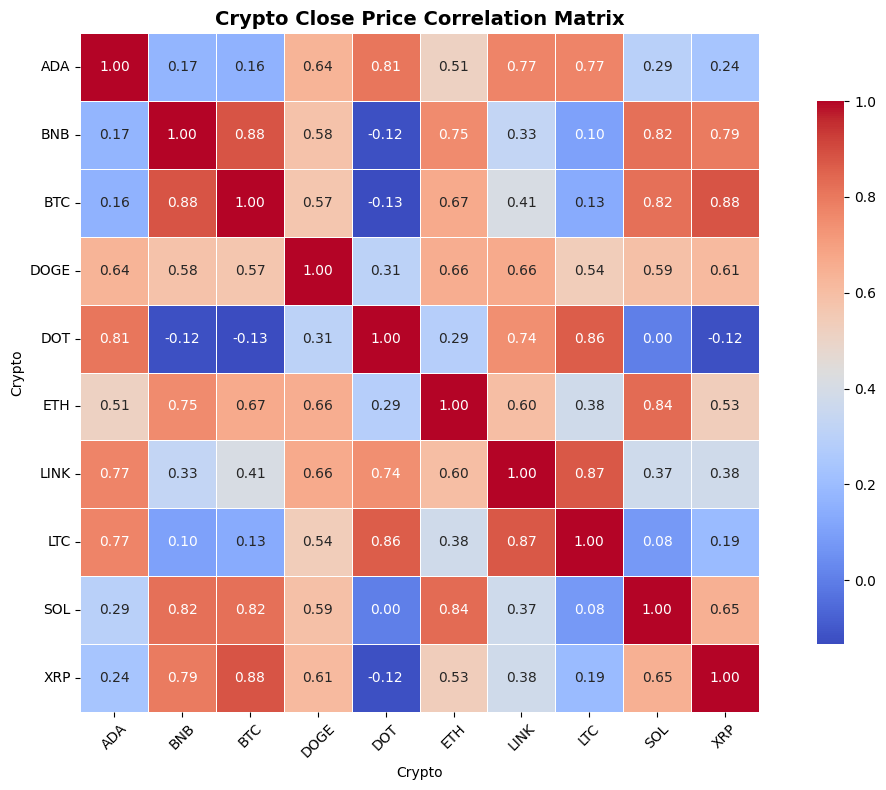

Saved: close_price_correlation.png


In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    close_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Crypto Close Price Correlation Matrix", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/correlation/close_price_correlation.png", dpi=150)
plt.show()
print("Saved: close_price_correlation.png")

## Pivot Daily Returns & Compute Correlation
Daily returns correlation is more meaningful than price correlation because:
- It removes the effect of long-term upward trends
- It captures actual co-movement between assets
- It is the standard approach used in financial analysis

In [ ]:
returns_pivot = df.pivot(index="Date", columns="Crypto", values="Daily_Return")

returns_corr = returns_pivot.corr()

print("Daily Returns Correlation Matrix:")
print(returns_corr)

Daily Returns Correlation Matrix:
Crypto       ADA       BNB       BTC      DOGE       DOT       ETH      LINK  \
Crypto                                                                         
ADA     1.000000  0.536637  0.653424  0.338644  0.707832  0.686881  0.692852   
BNB     0.536637  1.000000  0.632513  0.240346  0.600416  0.638502  0.585548   
BTC     0.653424  0.632513  1.000000  0.390882  0.692711  0.805702  0.684167   
DOGE    0.338644  0.240346  0.390882  1.000000  0.341526  0.357791  0.339559   
DOT     0.707832  0.600416  0.692711  0.341526  1.000000  0.743178  0.746440   
ETH     0.686881  0.638502  0.805702  0.357791  0.743178  1.000000  0.760656   
LINK    0.692852  0.585548  0.684167  0.339559  0.746440  0.760656  1.000000   
LTC     0.640267  0.587232  0.706733  0.354421  0.721242  0.738301  0.714562   
SOL     0.574372  0.555447  0.603115  0.262281  0.590564  0.646474  0.584558   
XRP     0.611089  0.479267  0.563873  0.247797  0.564099  0.572405  0.585374   

Crypt

## Heatmap — Daily Returns Correlation
Visualize the daily returns correlation matrix.
This is the **primary correlation metric** used for financial analysis
as it reflects true co-movement between cryptocurrency returns.

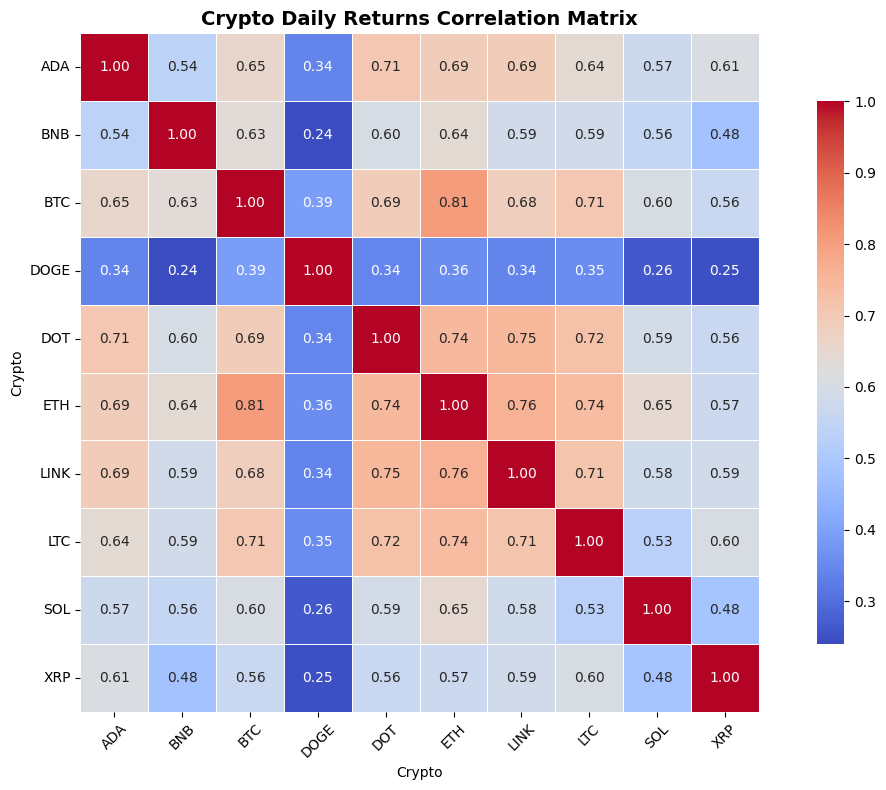

Saved: returns_correlation.png


In [ ]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    returns_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)
plt.title("Crypto Daily Returns Correlation Matrix", fontsize=14, fontweight="bold")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("../data/correlation/returns_correlation.png", dpi=150)
plt.show()
print("Saved: returns_correlation.png")

## Pairplot — Top 5 Cryptocurrencies
Generate a pairplot for the top 5 cryptocurrencies by market capitalization:
**BTC, ETH, BNB, XRP, SOL**

- **Diagonal:** KDE (Kernel Density Estimate) of individual return distributions
- **Off-diagonal:** Scatter plots showing pairwise return relationships

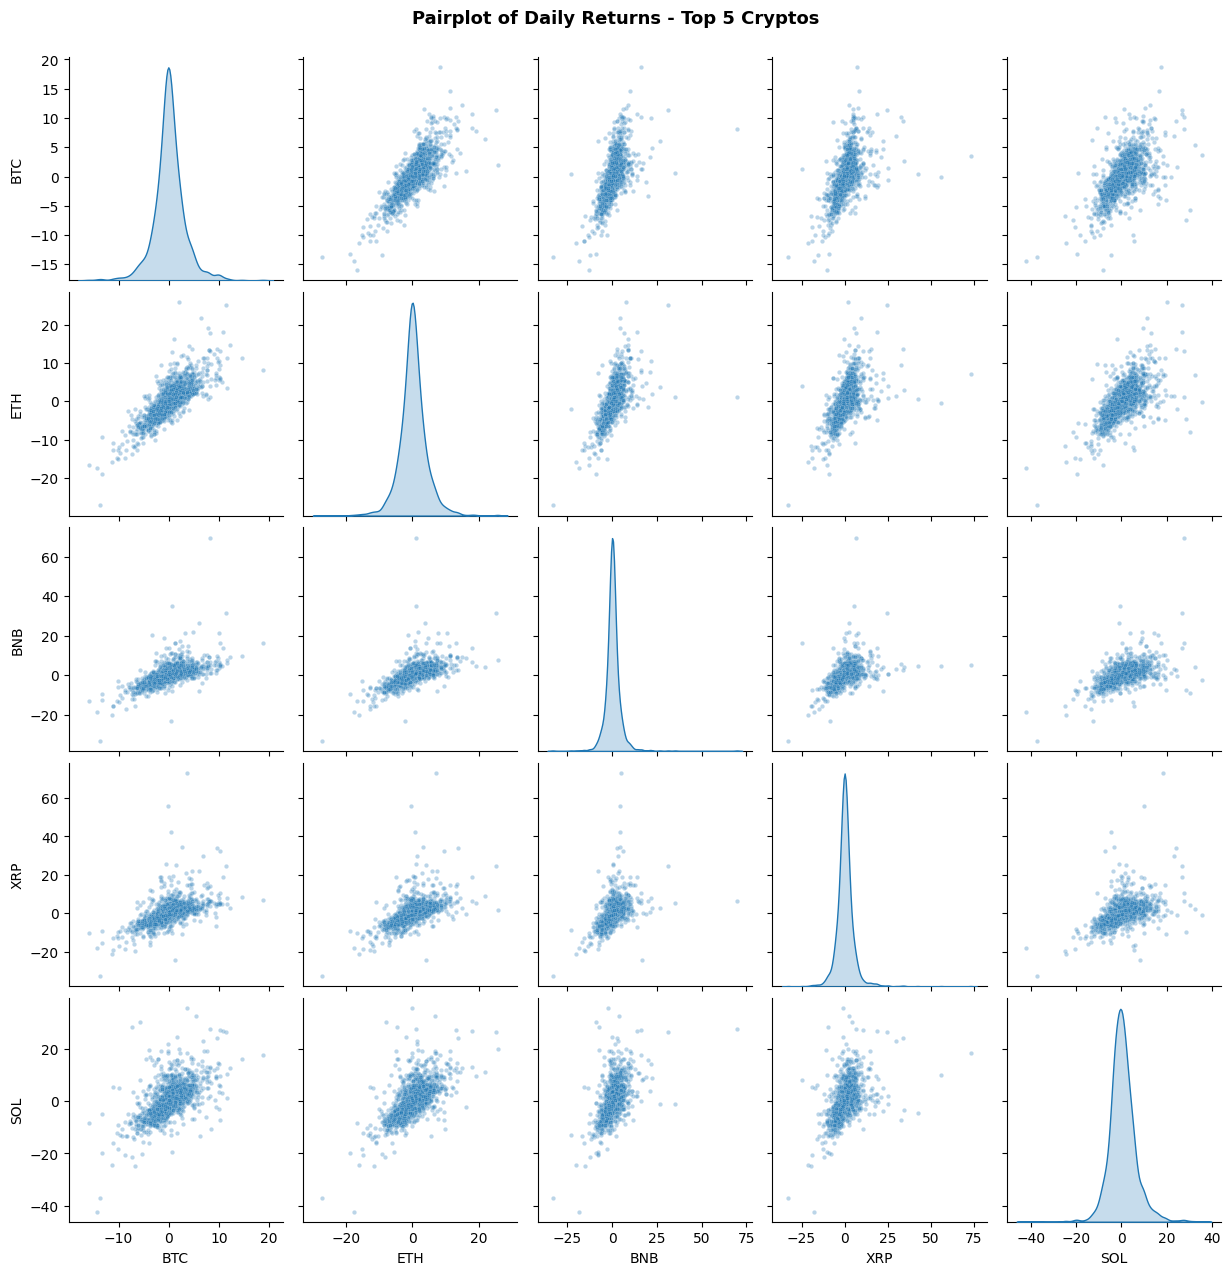

Saved: pairplot_top5.png


In [ ]:
top5 = ["BTC", "ETH", "BNB", "XRP", "SOL"]
returns_top5 = returns_pivot[top5].dropna()

sns.pairplot(returns_top5, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
plt.suptitle("Pairplot of Daily Returns - Top 5 Cryptos", y=1.02, fontsize=13, fontweight="bold")
plt.savefig("../data/correlation/pairplot_top5.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: pairplot_top5.png")

## 30-Day Rolling Correlation with BTC
Bitcoin is the dominant cryptocurrency and often drives market sentiment.
This chart shows how the 30-day rolling correlation between BTC and other
major cryptocurrencies changes over time.

- **High correlation** → coin moves closely with Bitcoin
- **Low / negative correlation** → coin moves independently

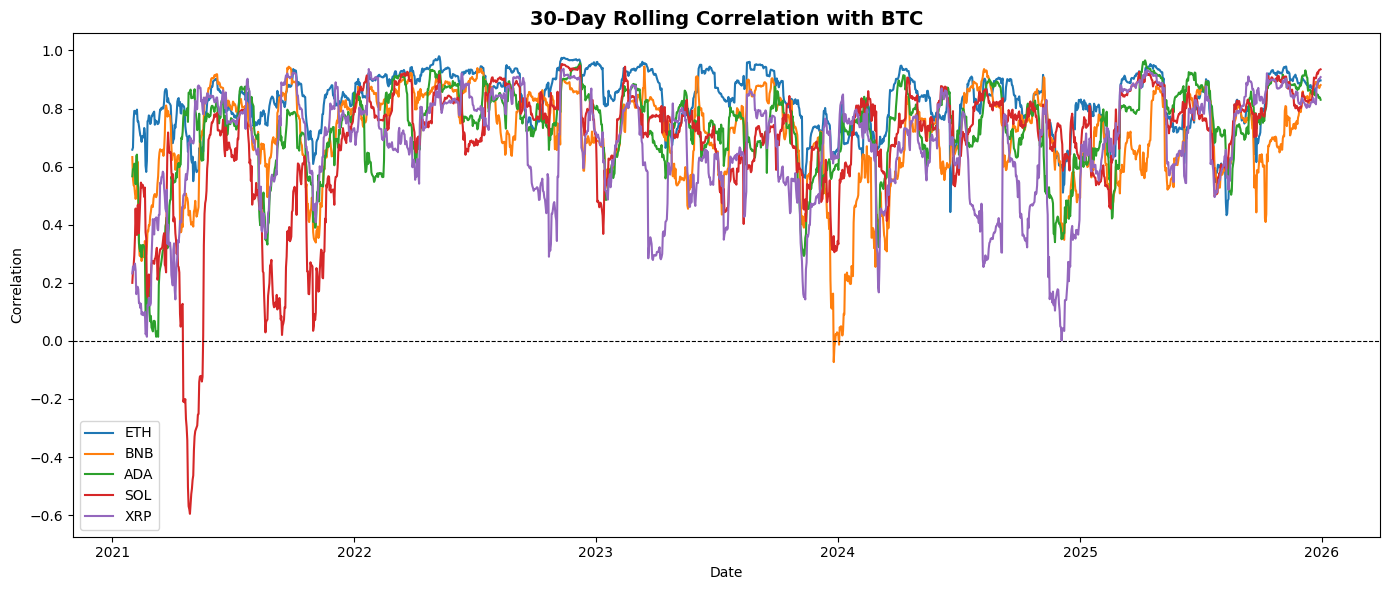

Saved: rolling_correlation_btc.png


In [ ]:
plt.figure(figsize=(14, 6))

for crypto in ["ETH", "BNB", "ADA", "SOL", "XRP"]:
    rolling_corr = returns_pivot["BTC"].rolling(30).corr(returns_pivot[crypto])
    plt.plot(rolling_corr.index, rolling_corr, label=crypto)

plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.title("30-Day Rolling Correlation with BTC", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Correlation")
plt.legend(loc="lower left")
plt.tight_layout()
plt.savefig("../data/correlation/rolling_correlation_btc.png", dpi=150)
plt.show()
print("Saved: rolling_correlation_btc.png")

## Most & Least Correlated Pairs
Identify the cryptocurrency pairs with the strongest and weakest
return correlations across the entire dataset.

- **Most correlated pairs** move together — less diversification benefit
- **Least correlated pairs** move independently — better for portfolio diversification

In [ ]:
corr_unstacked = returns_corr.unstack()
corr_unstacked = corr_unstacked[corr_unstacked < 1.0]
corr_unstacked = corr_unstacked.drop_duplicates()

print("Top 5 Most Correlated Pairs:")
print(corr_unstacked.sort_values(ascending=False).head(5))

print("\nTop 5 Least Correlated Pairs:")
print(corr_unstacked.sort_values(ascending=True).head(5))

Top 5 Most Correlated Pairs:
Crypto  Crypto
BTC     ETH       0.805702
ETH     LINK      0.760656
DOT     LINK      0.746440
        ETH       0.743178
ETH     LTC       0.738301
dtype: float64

Top 5 Least Correlated Pairs:
Crypto  Crypto
BNB     DOGE      0.240346
DOGE    XRP       0.247797
        SOL       0.262281
ADA     DOGE      0.338644
DOGE    LINK      0.339559
dtype: float64


## Save Correlation Matrices
Save both correlation matrices as CSV files for use in
Power BI dashboard and model comparison notebook.

**Output files saved to `../data/correlation/`:**
- `close_price_correlation.csv`
- `returns_correlation.csv`

In [ ]:
close_corr.to_csv("../data/correlation/close_price_correlation.csv")
returns_corr.to_csv("../data/correlation/returns_correlation.csv")

print("Saved: close_price_correlation.csv")
print("Saved: returns_correlation.csv")

Saved: close_price_correlation.csv
Saved: returns_correlation.csv


## Summary

| Output | Description | Location |
|--------|-------------|----------|
| close_price_correlation.png | Close price heatmap | data/correlation/ |
| returns_correlation.png | Daily returns heatmap | data/correlation/ |
| pairplot_top5.png | Pairplot top 5 cryptos | data/correlation/ |
| rolling_correlation_btc.png | 30-day rolling vs BTC | data/correlation/ |
| close_price_correlation.csv | Correlation matrix | data/correlation/ |
| returns_correlation.csv | Returns matrix | data/correlation/ |

**Key Insight:** Most cryptocurrencies show strong positive correlation
with Bitcoin, indicating high market dependency and limited diversification
opportunities within the crypto asset class.

**Next Step:** `04_volatility_analysis.ipynb`